In [1]:
#importing the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#loading the dataset
df = pd.read_csv('nepal_house_data.csv')

In [3]:
pd.set_option('display.max_rows', False)

# Performing EDA

In [4]:
#Displaying the shape of the dataset
df.shape

(1000, 15)

In [5]:
df.head()

,location,land_area_sqft,floors,bedrooms,bathrooms,windows,doors,cement_bags,rcc_structure,plumbing,electricity,land_cost,construction_cost,material_cost,total_price
0,Chitwan,1055,1,5,4,13,4,238,1,1,0,6857500,1899000,167460,9043960
1,Dhangadi,2779,2,6,3,9,8,253,1,1,1,15284500,10004400,181760,25670660
2,Pokhara,2018,1,6,2,11,8,405,1,0,0,18162000,3632400,252600,22047000
3,Pokhara,727,4,4,4,5,3,392,1,1,1,6543000,5234400,198640,12176040
4,Pokhara,1447,4,1,4,14,6,221,1,1,1,13023000,10418400,174820,23816220


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   location           1000 non-null   object
 1   land_area_sqft     1000 non-null   int64 
 2   floors             1000 non-null   int64 
 3   bedrooms           1000 non-null   int64 
 4   bathrooms          1000 non-null   int64 
 5   windows            1000 non-null   int64 
 6   doors              1000 non-null   int64 
 7   cement_bags        1000 non-null   int64 
 8   rcc_structure      1000 non-null   int64 
 9   plumbing           1000 non-null   int64 
 10  electricity        1000 non-null   int64 
 11  land_cost          1000 non-null   int64 
 12  construction_cost  1000 non-null   int64 
 13  material_cost      1000 non-null   int64 
 14  total_price        1000 non-null   int64 
dtypes: int64(14), object(1)
memory usage: 117.3+ KB


In [7]:
df.describe()

,land_area_sqft,floors,bedrooms,bathrooms,windows,doors,cement_bags,rcc_structure,plumbing,electricity,land_cost,construction_cost,material_cost,total_price
count,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.0,1000.00000,1000.000000,1.000000e+03,1.000000e+03,1000.000000,1.000000e+03
mean,1783.32400,2.517000,3.467000,2.482000,9.005000,5.12900,338.425000,1.0,0.49000,0.504000,1.330775e+07,8.040146e+06,201865.500000,2.164888e+07
std,696.19825,1.130924,1.716933,1.104036,3.202691,1.99558,91.084185,0.0,0.50015,0.500234,7.686120e+06,4.908555e+06,41585.304381,1.080656e+07
min,606.00000,1.000000,1.000000,1.000000,4.000000,2.00000,180.000000,1.0,0.00000,0.000000,2.428000e+06,1.092600e+06,107040.000000,3.876860e+06
25%,1184.75000,1.000000,2.000000,2.000000,6.000000,3.00000,259.750000,1.0,0.00000,0.000000,7.396750e+06,4.043250e+06,169005.000000,1.301385e+07
50%,1780.00000,3.000000,3.000000,2.000000,9.000000,5.00000,336.500000,1.0,0.00000,1.000000,1.122000e+07,7.027200e+06,201590.000000,2.003528e+07
75%,2381.50000,4.000000,5.000000,3.000000,12.000000,7.00000,416.000000,1.0,1.00000,1.000000,1.755975e+07,1.099575e+07,234900.000000,2.844340e+07
max,3000.00000,4.000000,6.000000,4.000000,14.000000,8.00000,500.000000,1.0,1.00000,1.000000,3.583200e+07,2.142000e+07,293480.000000,5.736834e+07


In [8]:
#Checking the duplicate datas
df.duplicated().sum()

np.int64(0)

Not a single duplicated value was found.

In [9]:
#Checking the null values
df.isnull().sum()

location             0
land_area_sqft       0
floors               0
bedrooms             0
bathrooms            0
windows              0
doors                0
cement_bags          0
rcc_structure        0
plumbing             0
electricity          0
land_cost            0
construction_cost    0
material_cost        0
total_price          0
dtype: int64

Not a single null vlaues was found.

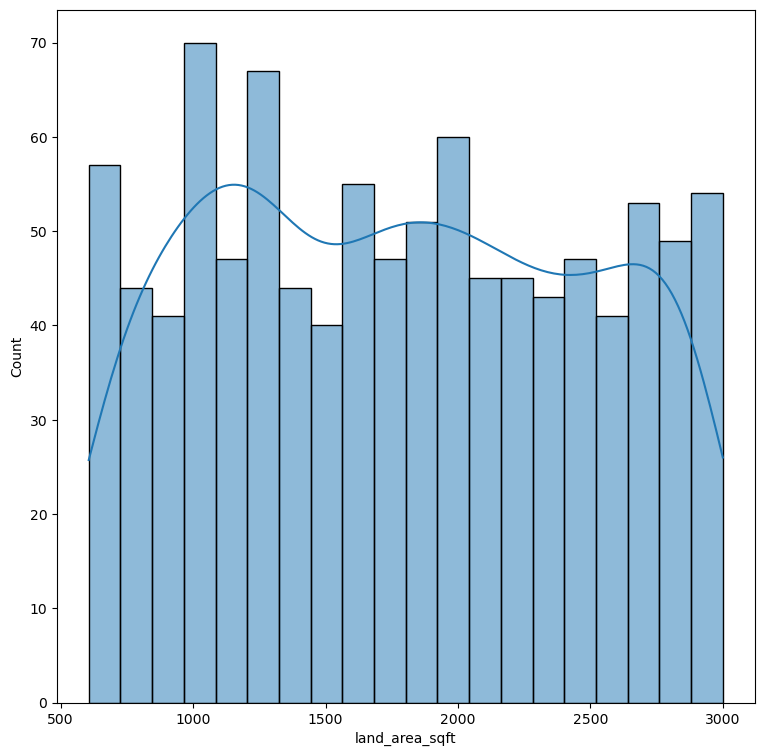

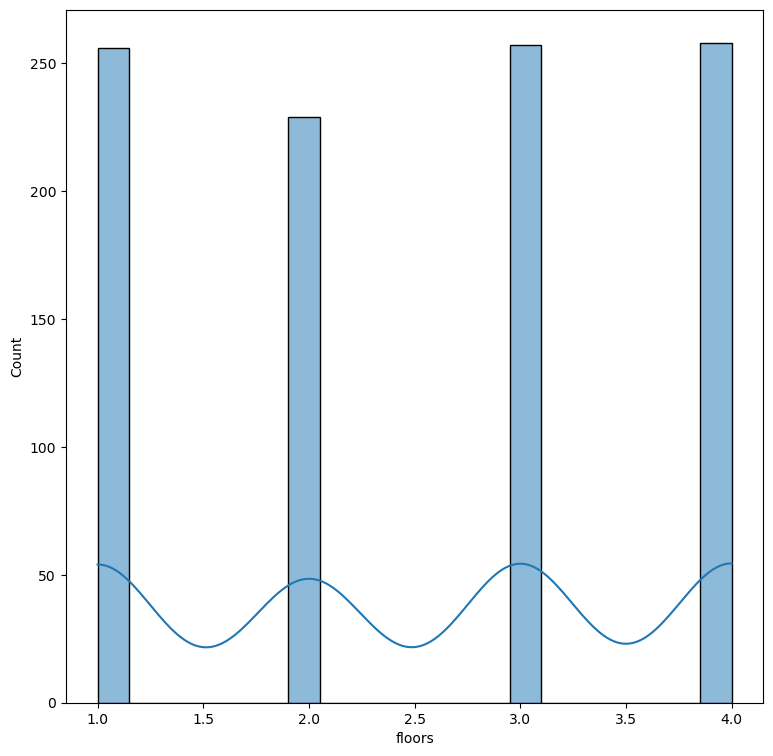

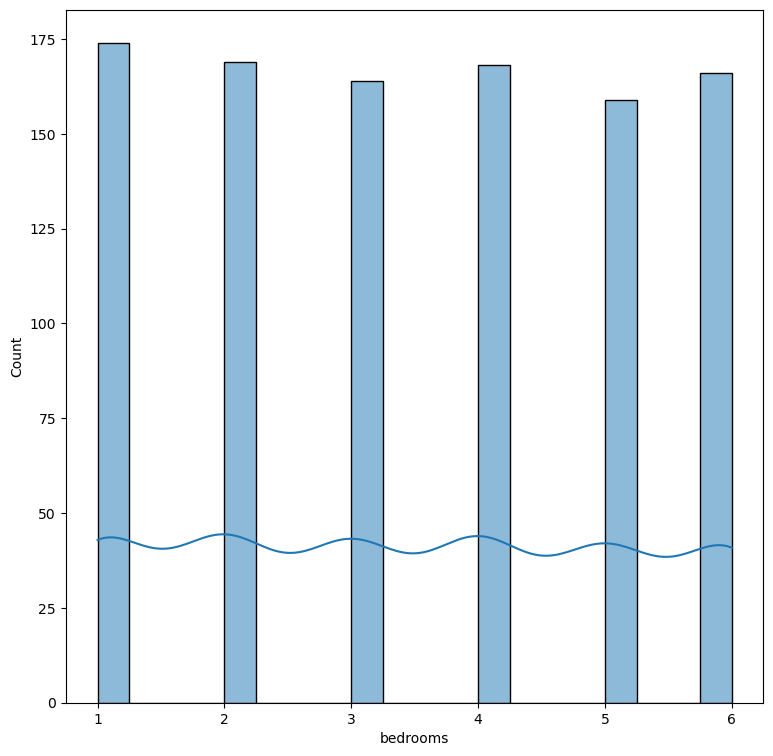

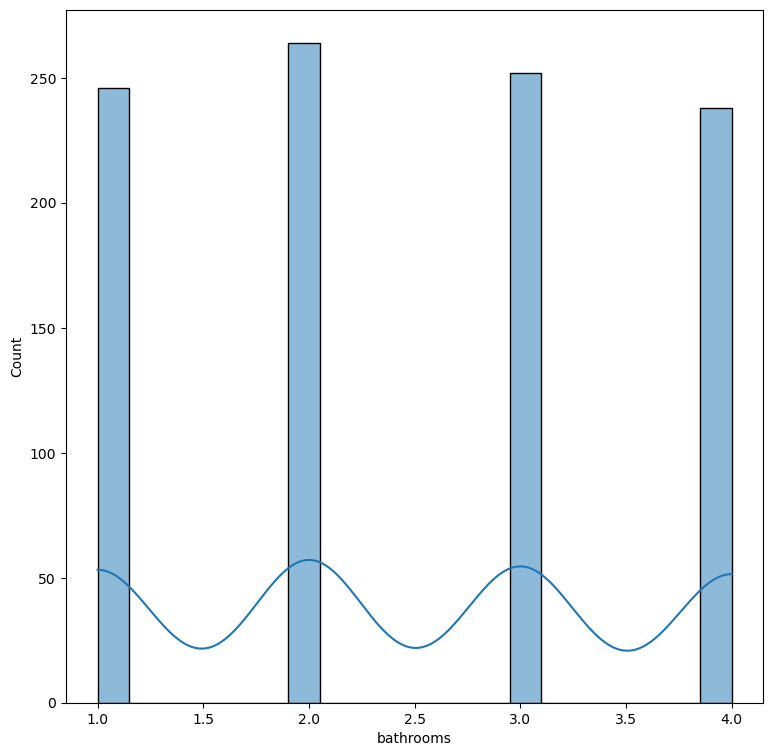

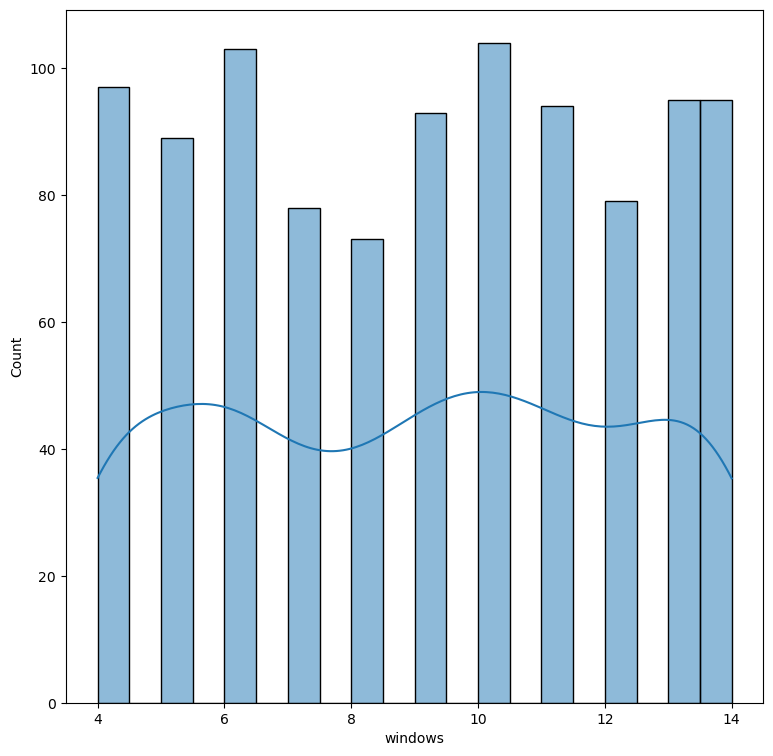

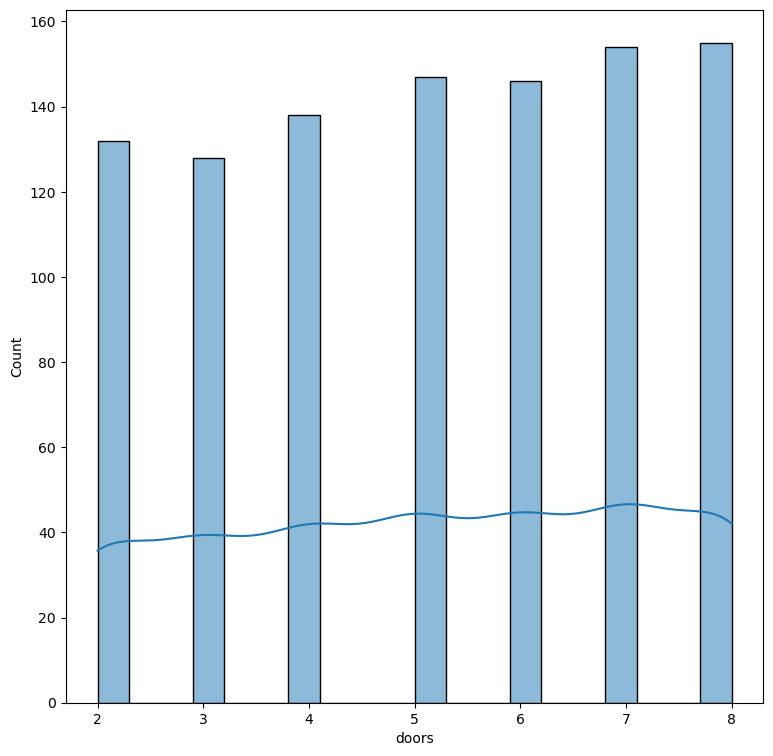

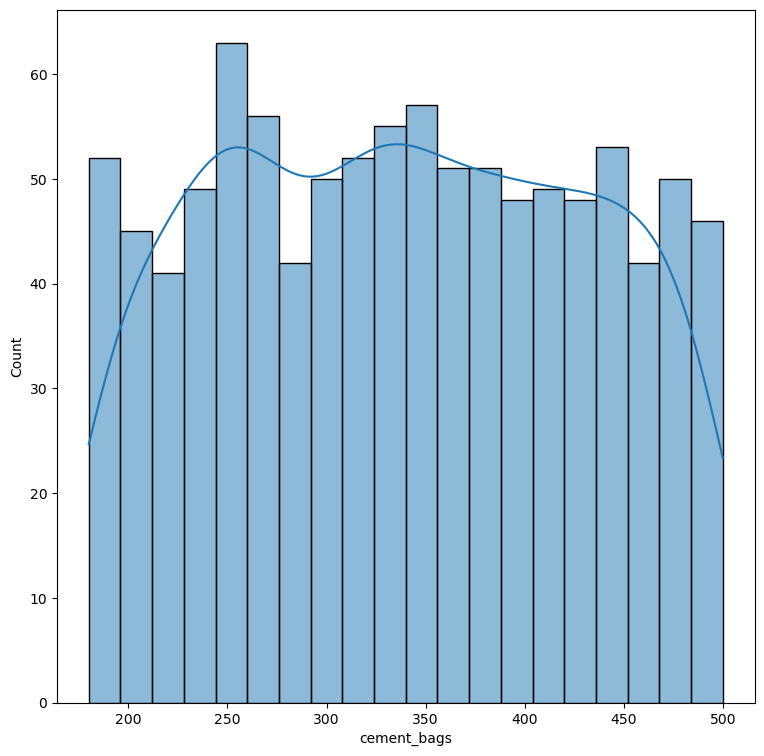

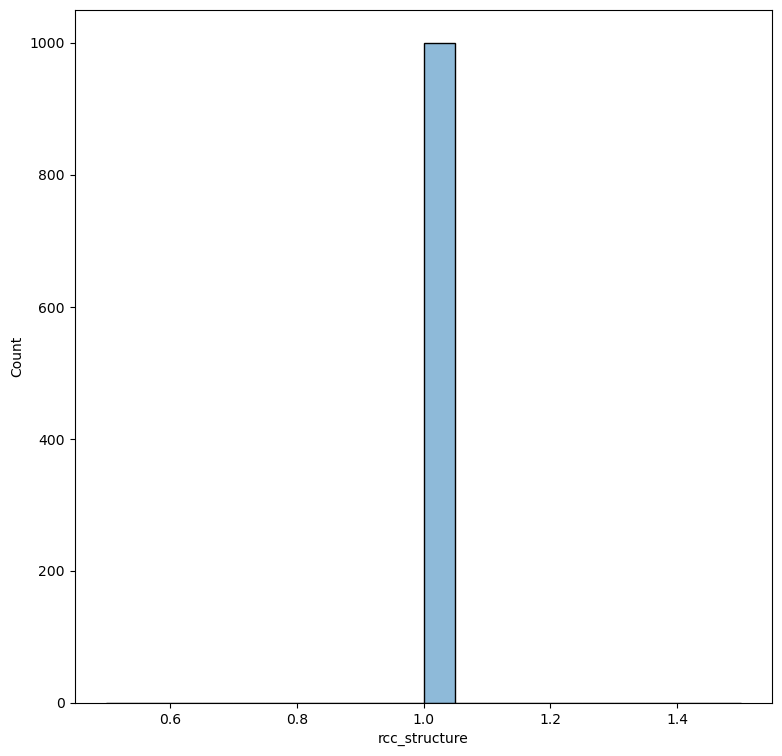

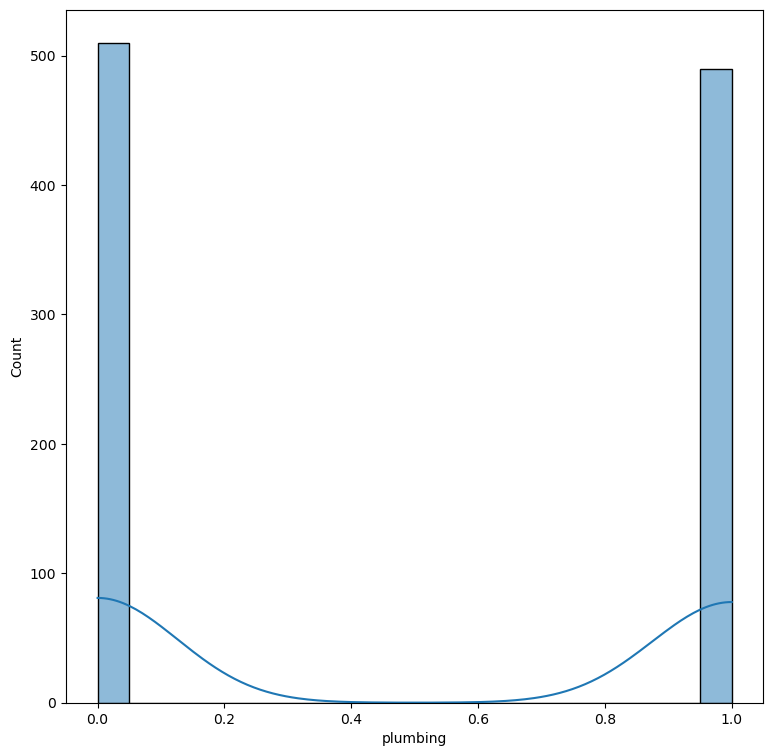

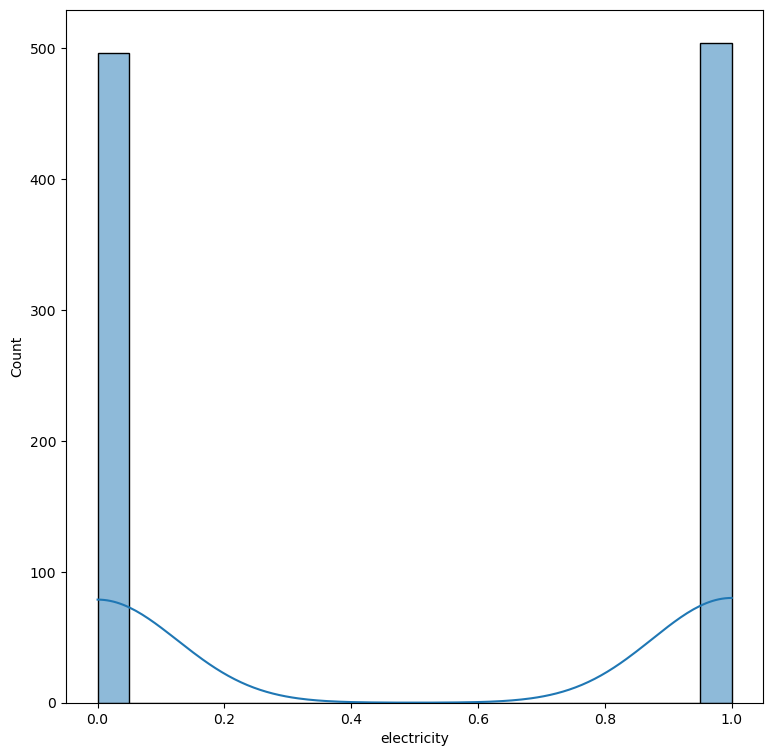

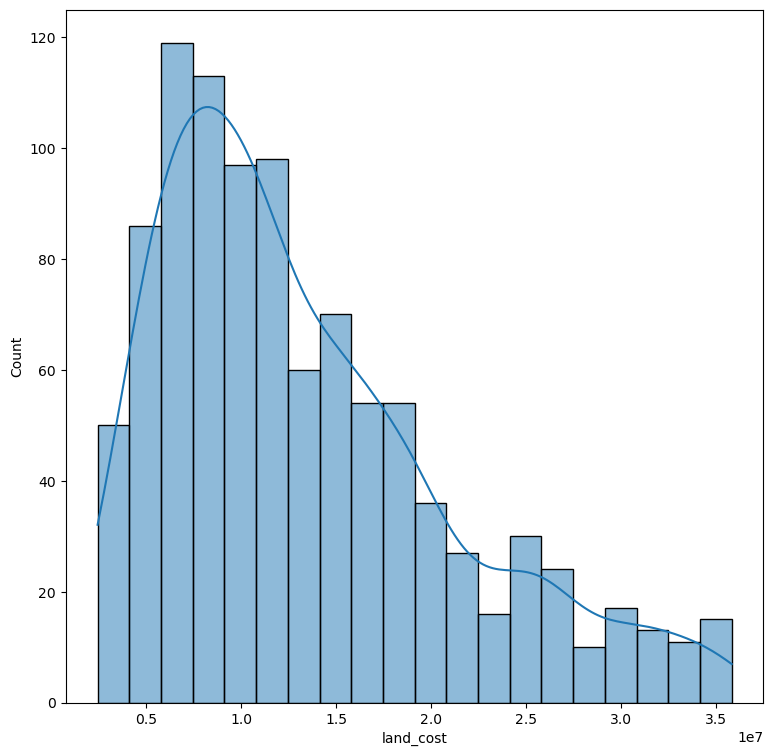

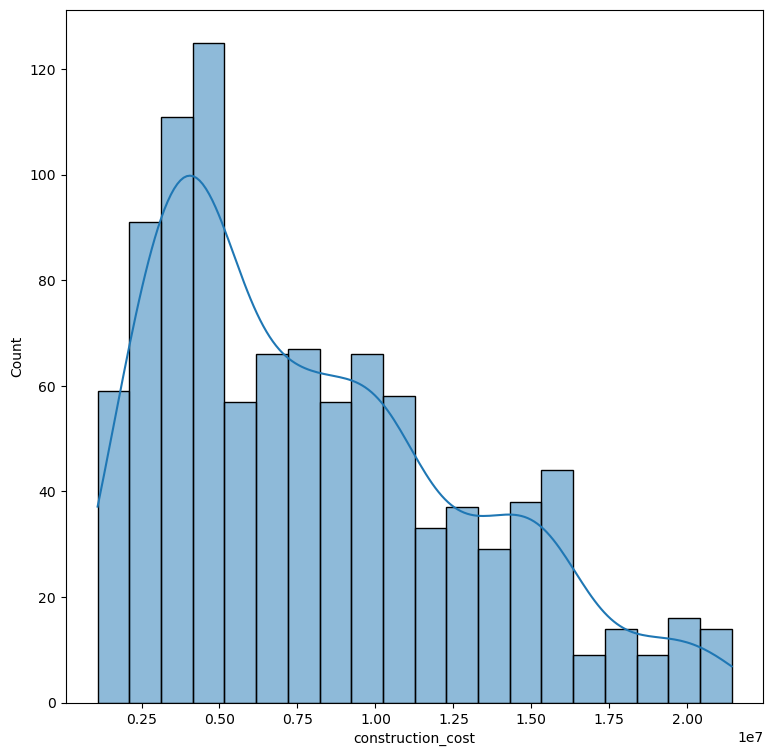

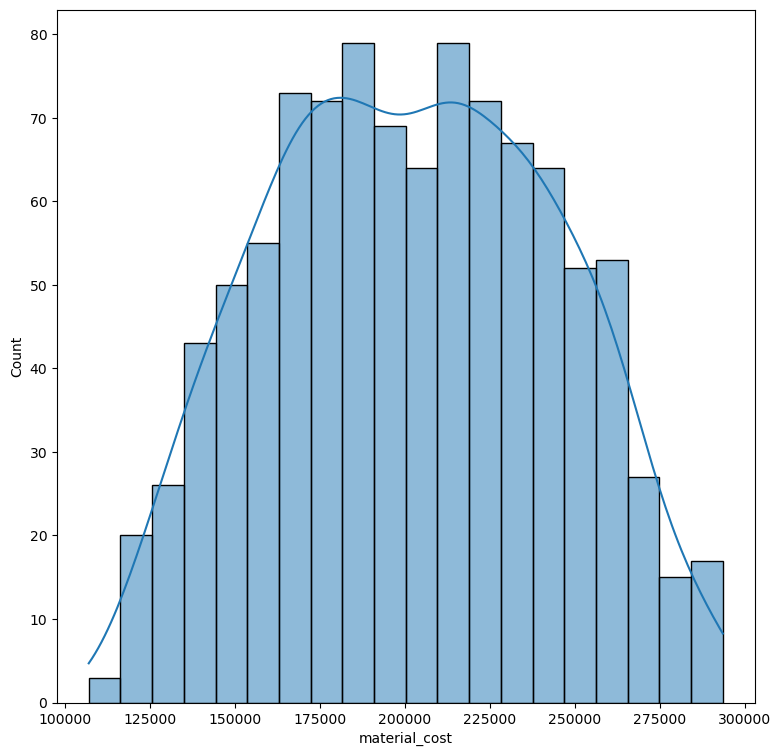

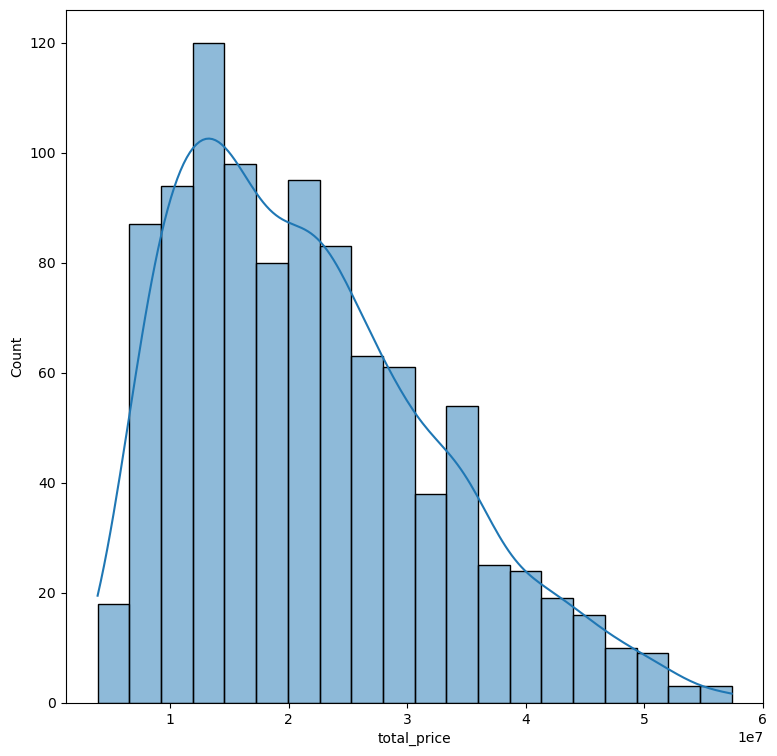

In [10]:
#Seperating the numeric column from the dataset and vewing the distribution among every numeric columns
numeric_columns = ['land_area_sqft', 'floors', 'bedrooms', 'bathrooms', 'windows', 'doors', 'cement_bags', 'rcc_structure', 'plumbing',
                   'electricity', 'land_cost', 'construction_cost', 'material_cost', 'total_price']
for col in numeric_columns:
    plt.figure(figsize=(9,9))
    sns.histplot(data=df[col], kde=True, bins=20)

successfully extracted all the numeric data from the data set with proper visualization of distribution of it.

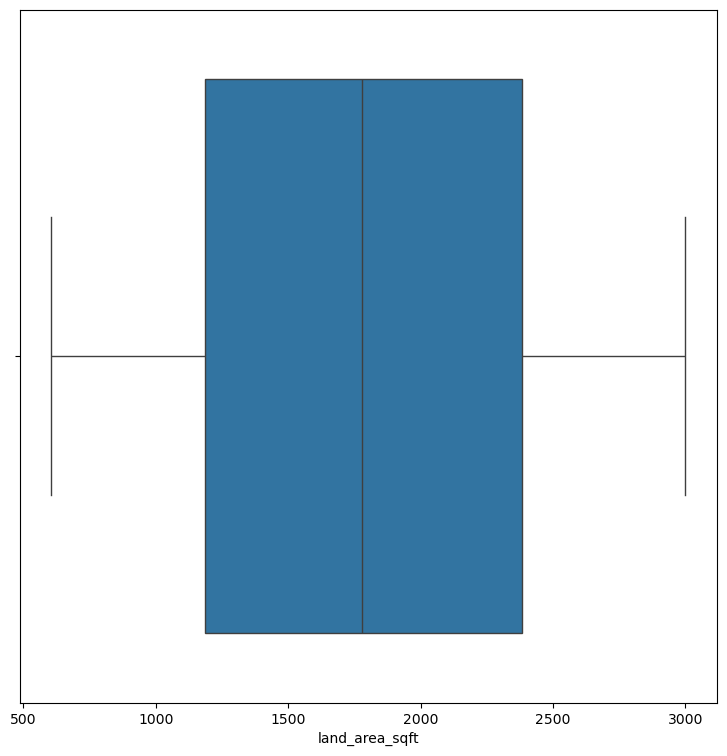

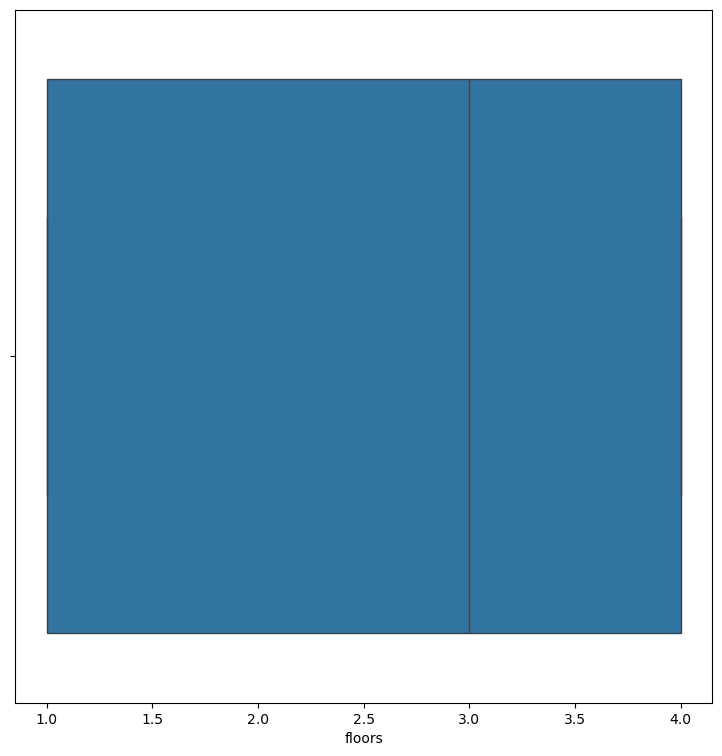

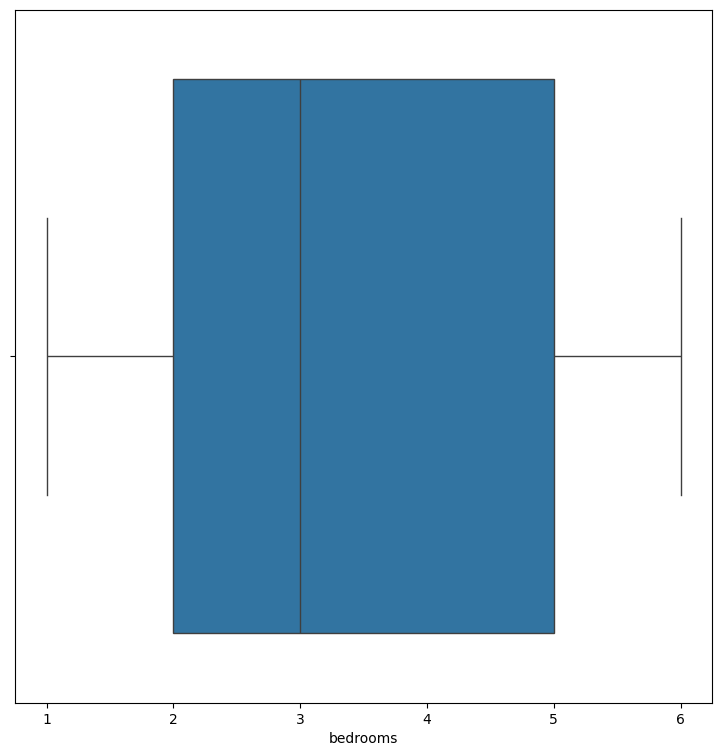

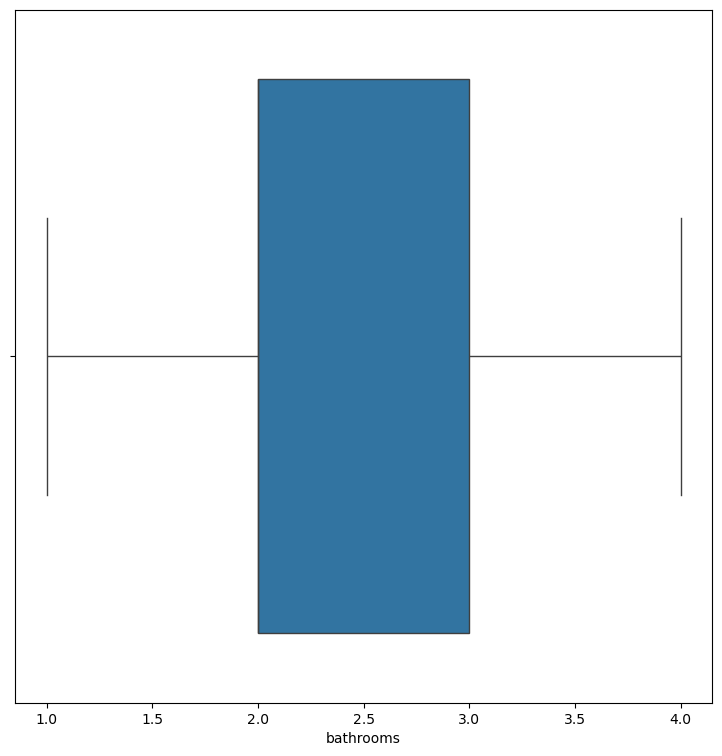

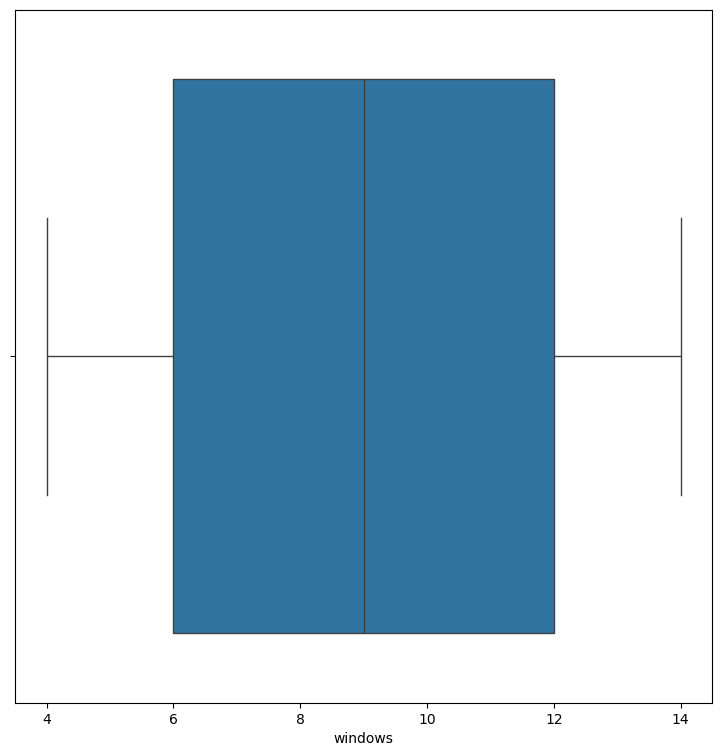

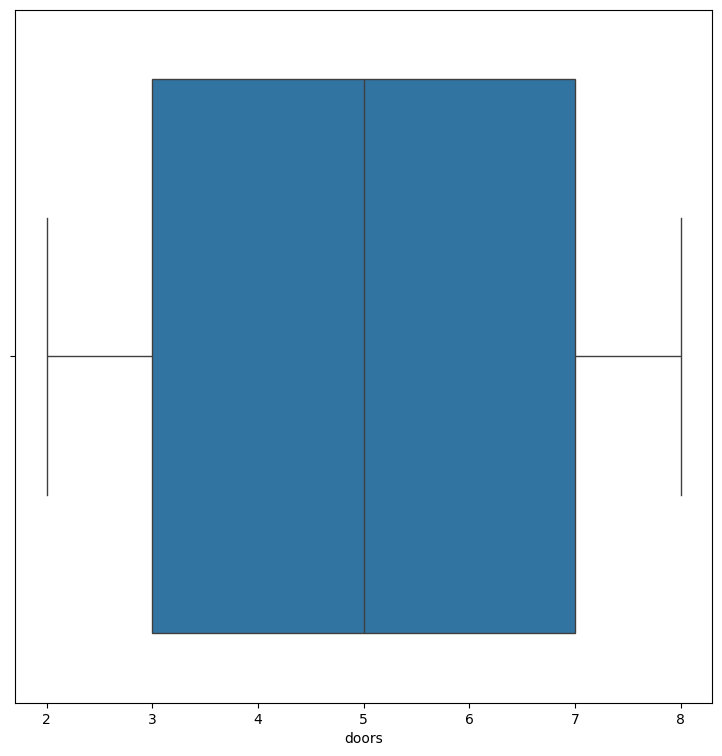

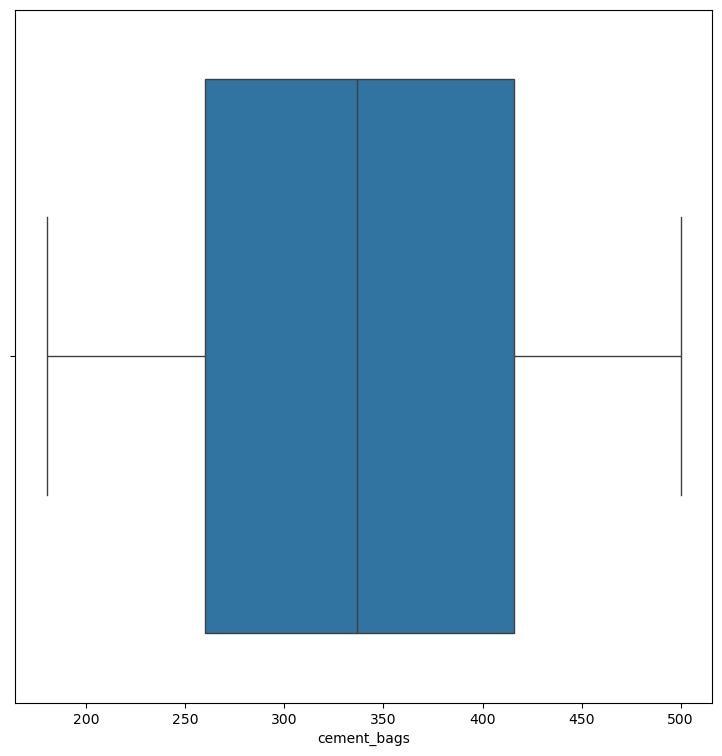

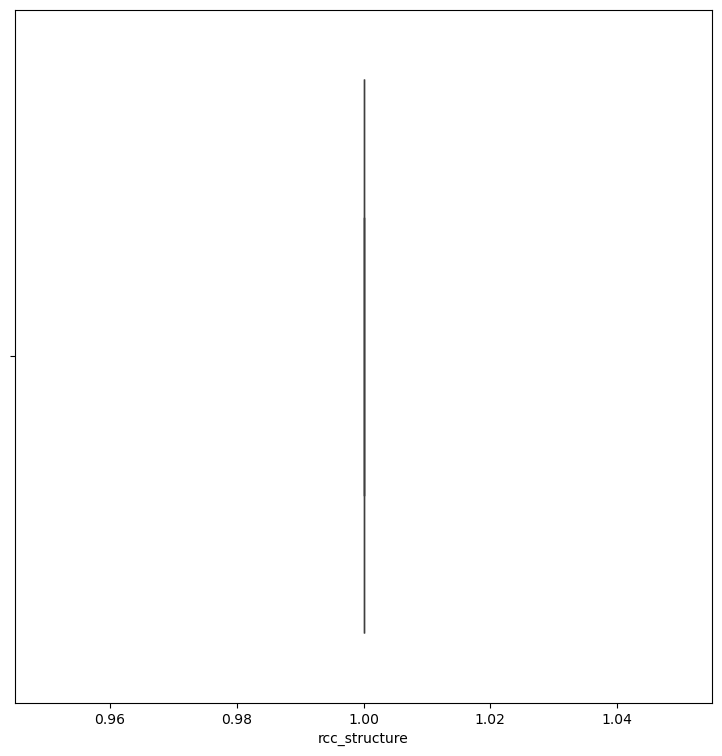

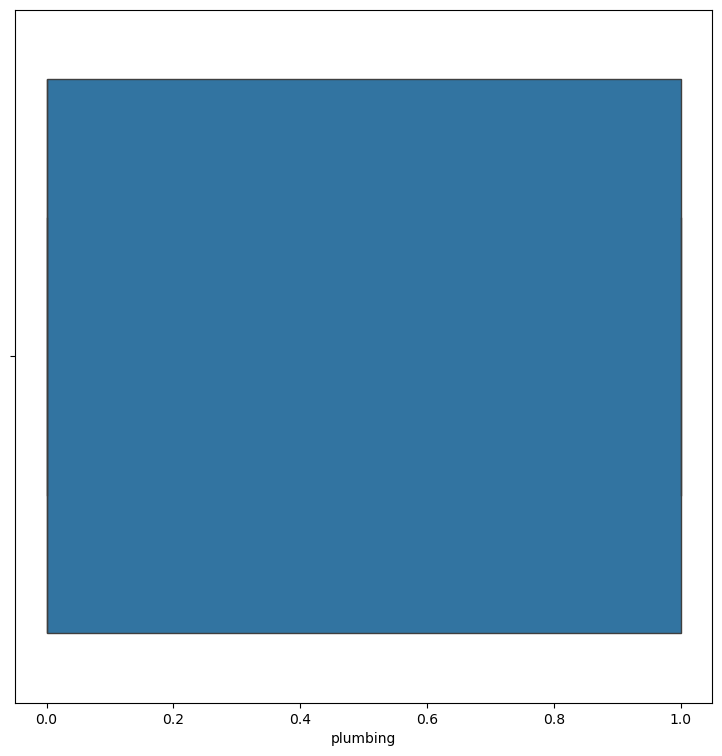

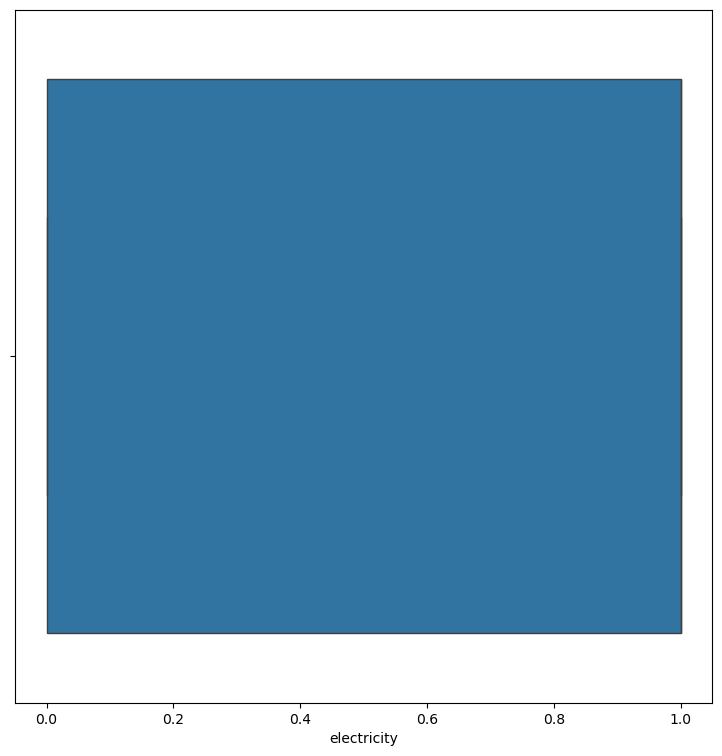

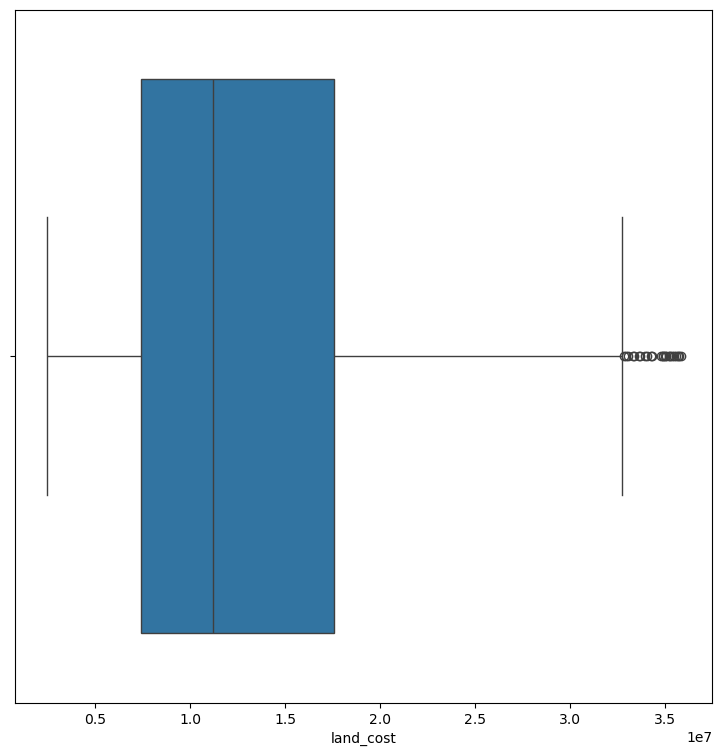

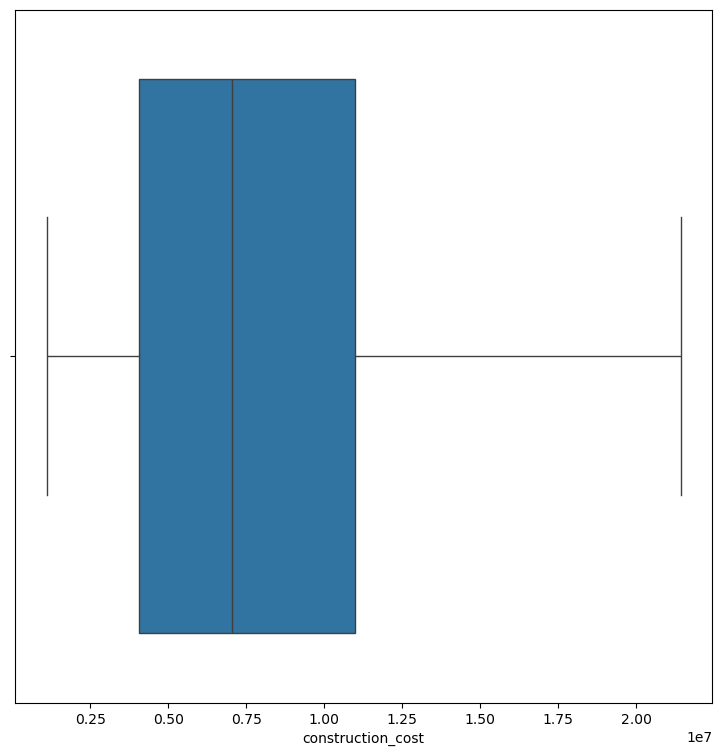

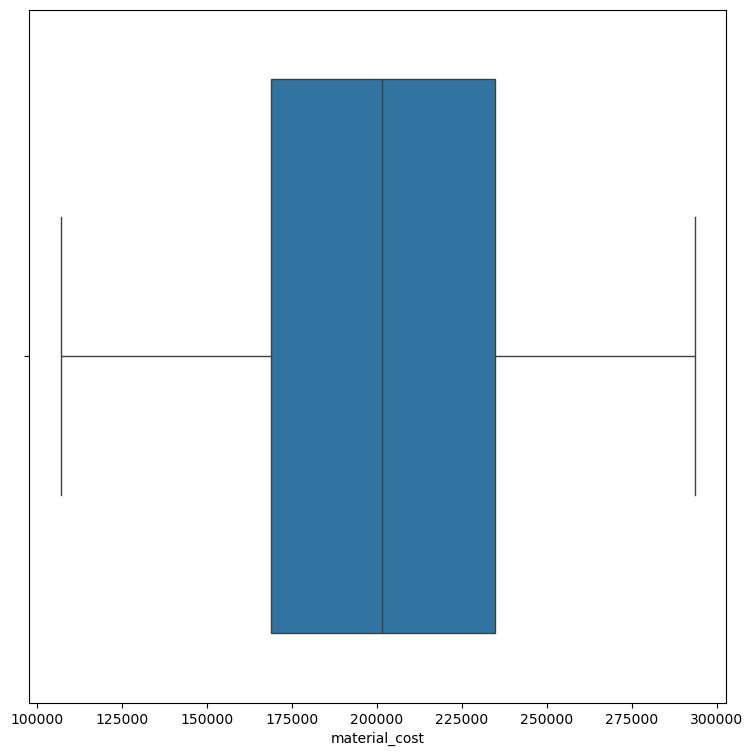

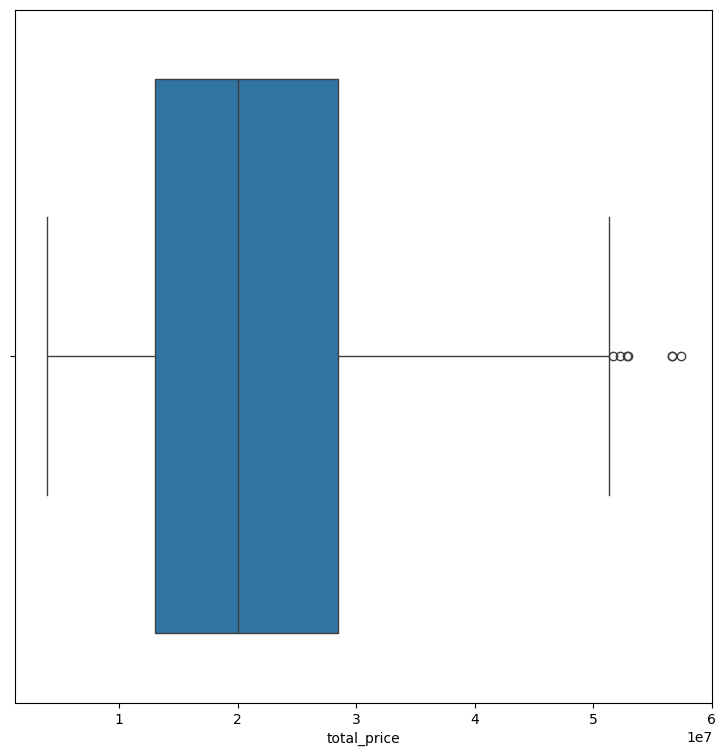

In [11]:
for col in numeric_columns:
    plt.figure(figsize=(9,9))
    sns.boxplot(x=df[col])

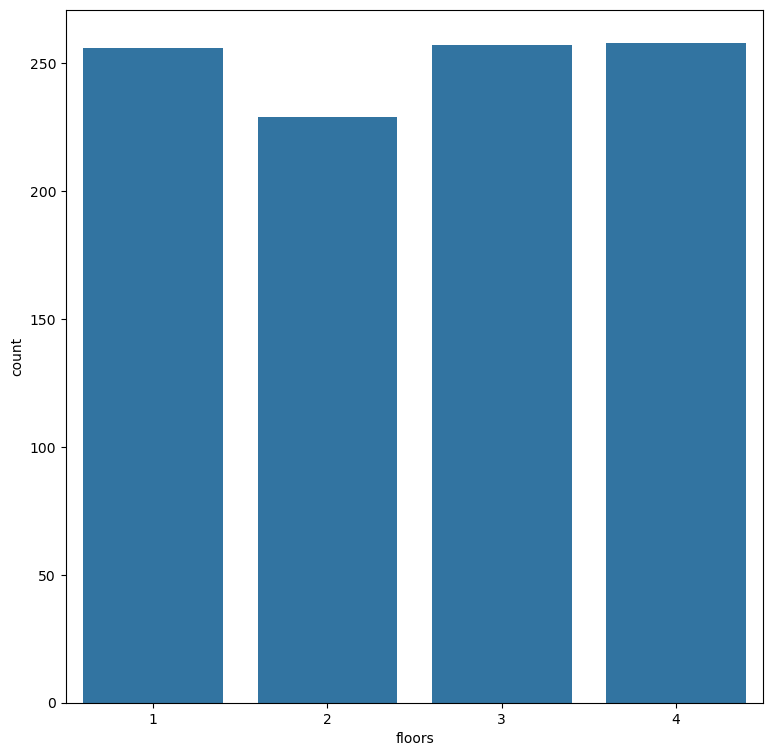

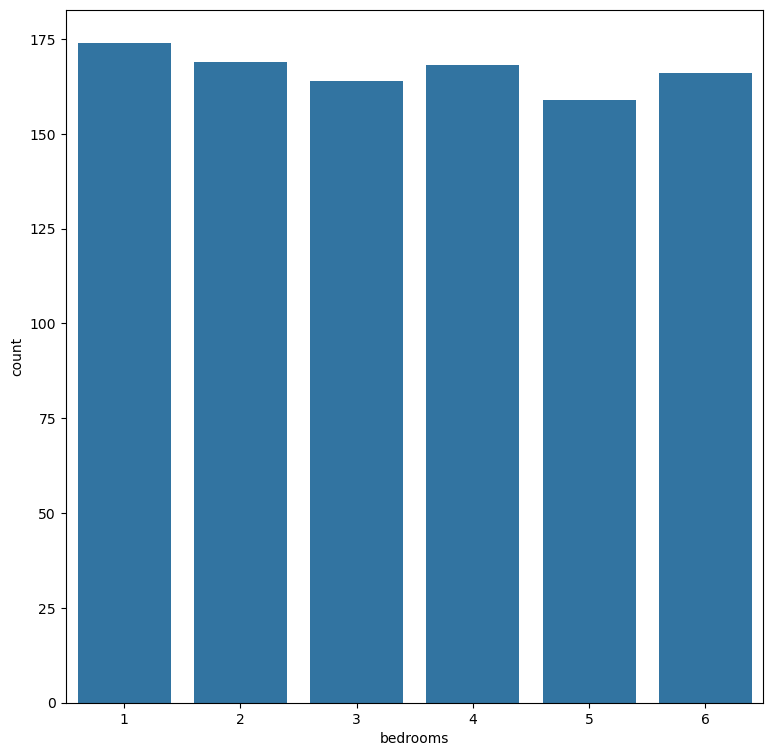

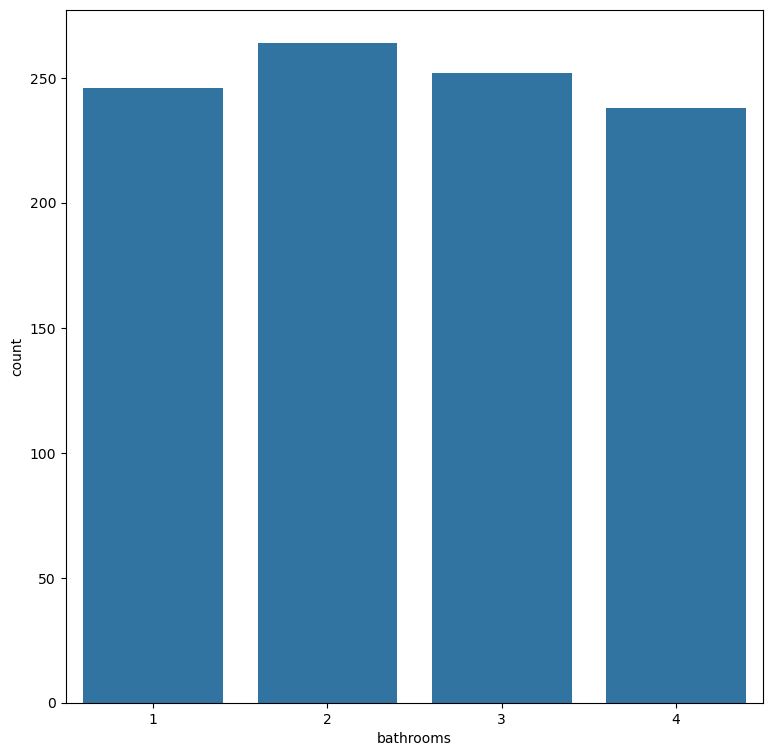

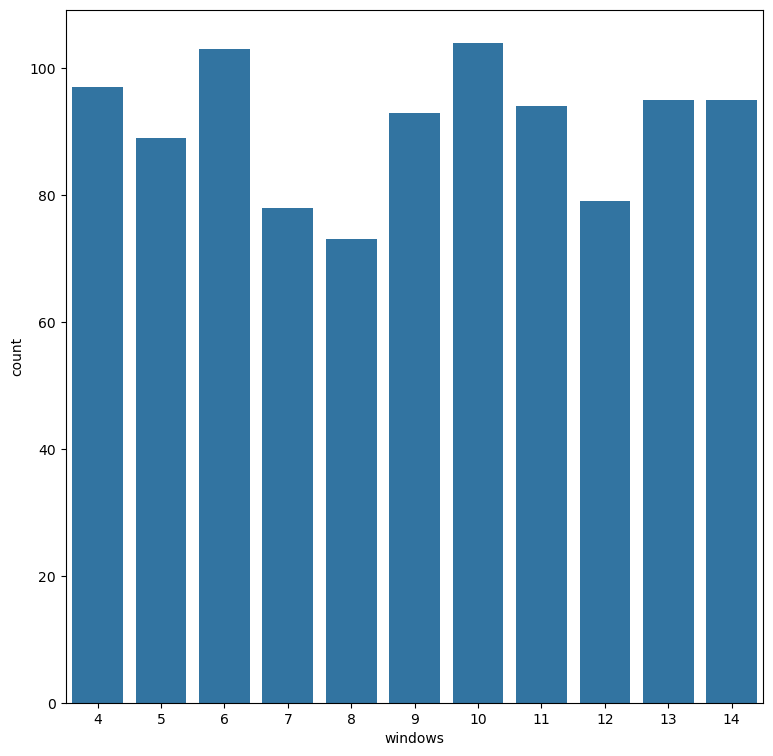

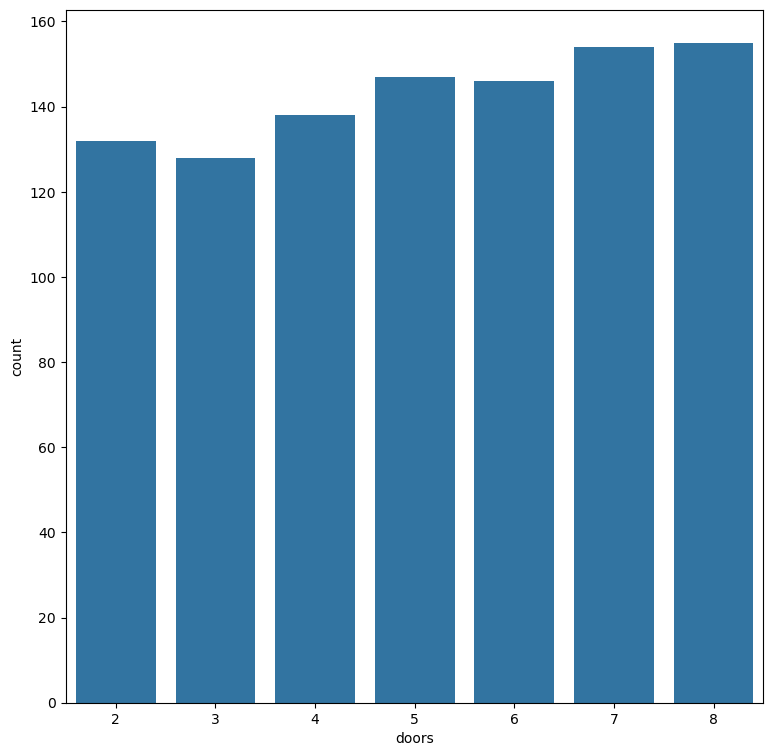

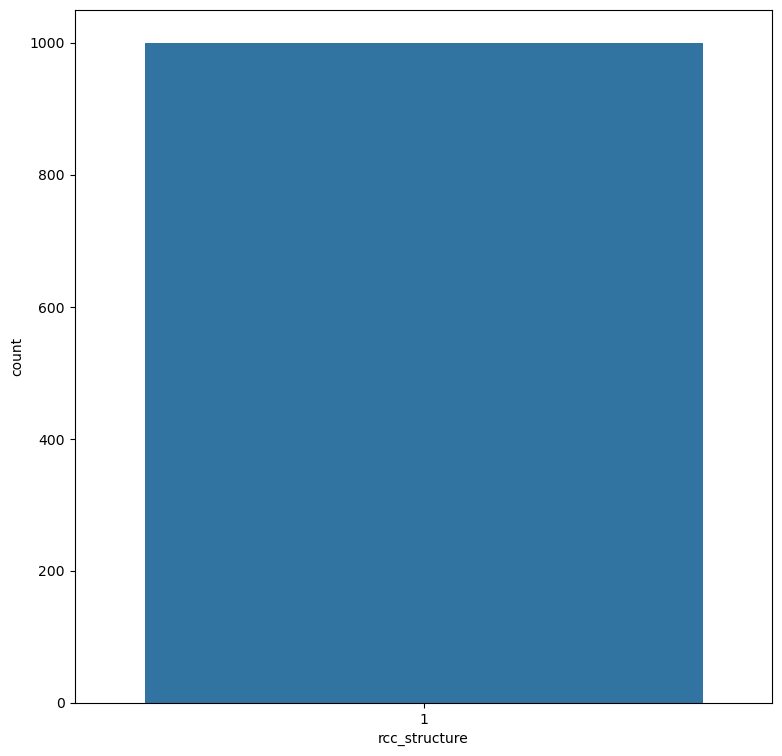

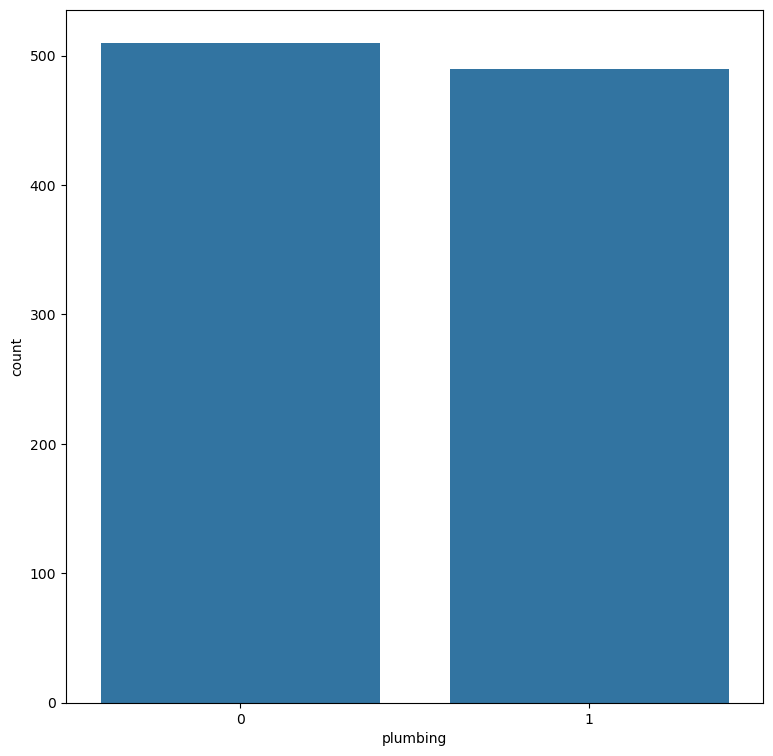

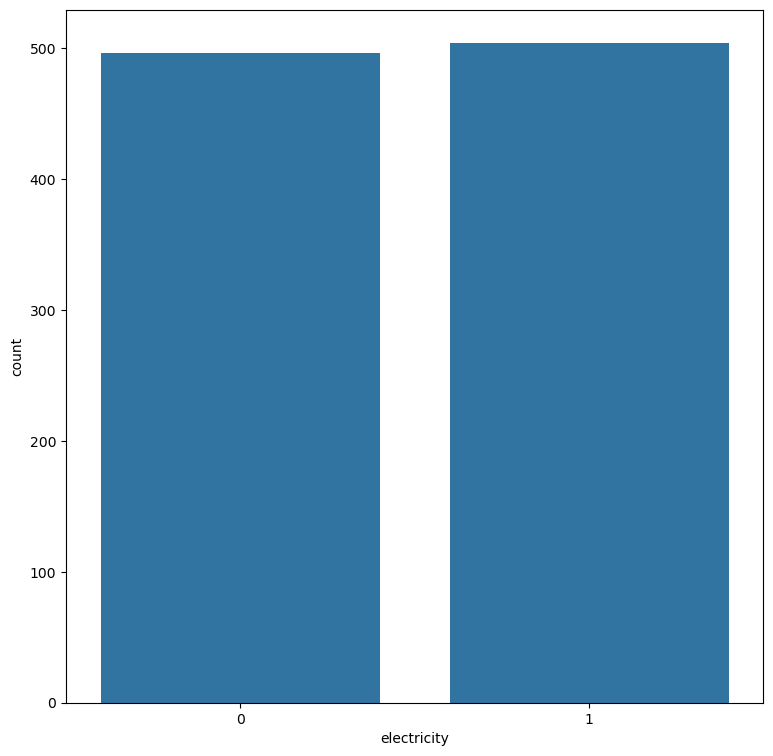

In [12]:
#Seperating the categorical column from the dataset and vewing the count of it.
categorical_columns = ['floors', 'bedrooms', 'bathrooms', 'windows', 'doors', 'rcc_structure', 'plumbing',
                   'electricity']
for col in categorical_columns:
    plt.figure(figsize=(9,9))
    sns.countplot(x = df[col])

Analysing the correlation among the categorical data

<Axes: >

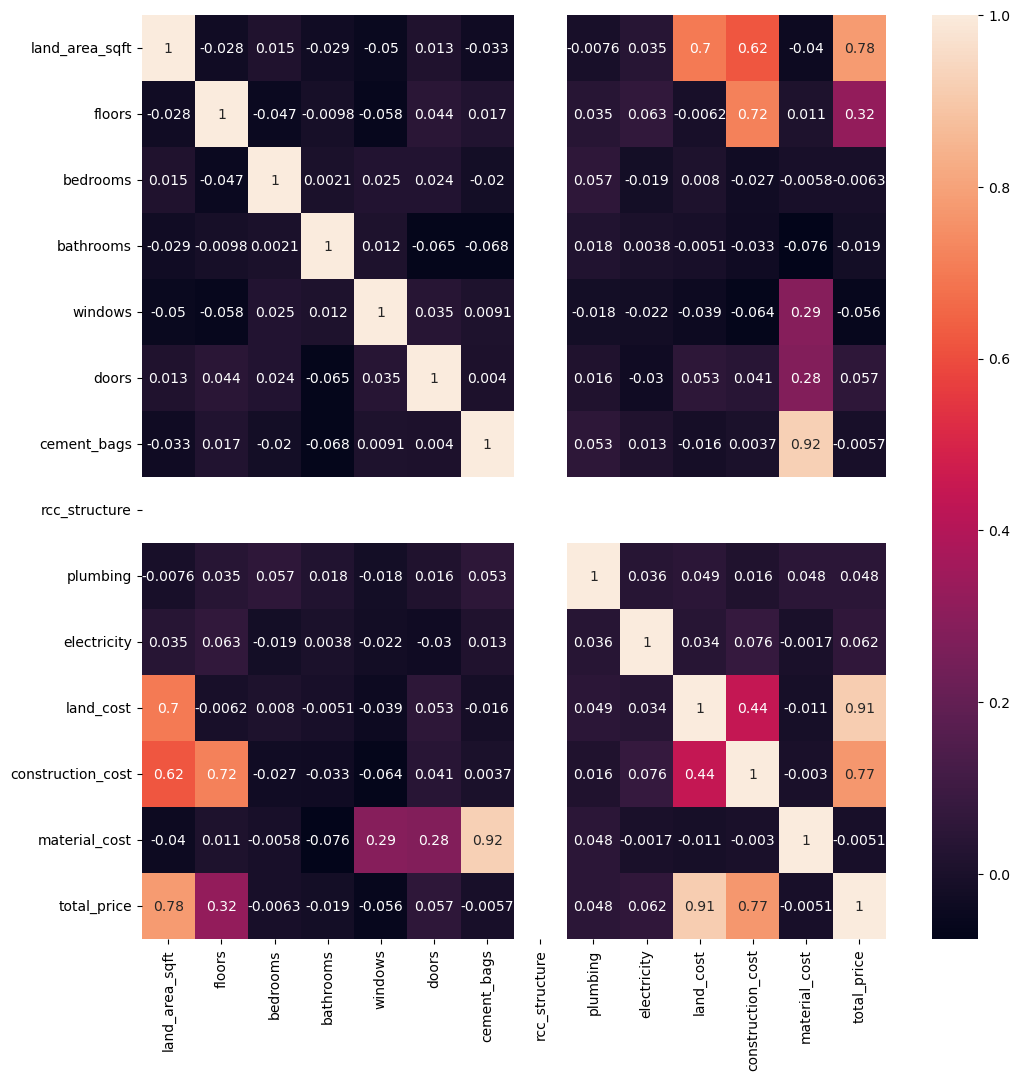

In [13]:
plt.figure(figsize=(12,12))
sns.heatmap(data= df.corr(numeric_only=True), annot=True)

# Data cleaning and data preprocessing

In [14]:
df_cleaned = df.copy()

In [15]:
#Checking the duplicate data in the dataset
df_cleaned.duplicated().sum()

np.int64(0)

In [16]:
#Checking the data types of the dataset
df_cleaned.dtypes

location             object
land_area_sqft        int64
floors                int64
bedrooms              int64
bathrooms             int64
windows               int64
doors                 int64
cement_bags           int64
rcc_structure         int64
plumbing              int64
electricity           int64
land_cost             int64
construction_cost     int64
material_cost         int64
total_price           int64
dtype: object

In [17]:
#Checking the nul values in the dataset
df_cleaned.isnull().sum()

location             0
land_area_sqft       0
floors               0
bedrooms             0
bathrooms            0
windows              0
doors                0
cement_bags          0
rcc_structure        0
plumbing             0
electricity          0
land_cost            0
construction_cost    0
material_cost        0
total_price          0
dtype: int64

# Feature Engineering and Extracting

In [18]:
df_cleaned = df_cleaned.drop(columns={'location'})

In [19]:
df_cleaned.head()

,land_area_sqft,floors,bedrooms,bathrooms,windows,doors,cement_bags,rcc_structure,plumbing,electricity,land_cost,construction_cost,material_cost,total_price
0,1055,1,5,4,13,4,238,1,1,0,6857500,1899000,167460,9043960
1,2779,2,6,3,9,8,253,1,1,1,15284500,10004400,181760,25670660
2,2018,1,6,2,11,8,405,1,0,0,18162000,3632400,252600,22047000
3,727,4,4,4,5,3,392,1,1,1,6543000,5234400,198640,12176040
4,1447,4,1,4,14,6,221,1,1,1,13023000,10418400,174820,23816220


In [20]:
# scaling the data
from sklearn.preprocessing import StandardScaler
columns = ['land_area_sqft', 'bedrooms', 'bathrooms', 'windows', 'doors', 'cement_bags', 'land_cost', 'construction_cost', 'material_cost']
scalar = StandardScaler()
df_cleaned[columns] = scalar.fit_transform(df_cleaned[columns])

In [21]:
df_cleaned.head()

,land_area_sqft,floors,bedrooms,bathrooms,windows,doors,cement_bags,rcc_structure,plumbing,electricity,land_cost,construction_cost,material_cost,total_price
0,-1.046668,1,0.893318,1.375643,1.248013,-0.566033,-1.103103,1,1,0,-0.839627,-1.251737,-0.827762,9043960
1,1.430877,2,1.476043,0.469422,-0.001562,1.439399,-0.938338,1,1,1,0.257314,0.400370,-0.483718,25670660
2,0.337251,1,1.476043,-0.436799,0.623225,1.439399,0.731283,1,0,0,0.631877,-0.898422,1.220621,22047000
3,-1.518034,4,0.310593,1.375643,-1.251136,-1.067391,0.588486,1,1,1,-0.880565,-0.571889,-0.077602,12176040
4,-0.483328,4,-1.437583,1.375643,1.560406,0.436683,-1.289837,1,1,1,-0.037065,0.484754,-0.650687,23816220


# Finding the correlation between the total_price and all other features to remove the features with negative or less correlation values

In [22]:
selected_features = ['land_area_sqft', 'floors', 'bedrooms', 'bathrooms', 'windows', 'doors', 'cement_bags', 'rcc_structure',
                  'plumbing', 'electricity', 'land_cost', 'construction_cost', 'material_cost']

In [23]:
from scipy.stats import pearsonr

#here [0] index is used because the pearsonr give two output as tuple (corr_cofficient, p_value)
correlations = {column: pearsonr(df_cleaned[column], df_cleaned['total_price'])[0] for column in selected_features}

correlation_df = pd.DataFrame(list(correlations.items()), columns=['feature', 'correlation_cofficient'])

/var/folders/7v/zj6jwrvx0kvgr32nv_qk55w80000gn/T/ipykernel_75684/3284945781.py:4: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlations = {column: pearsonr(df_cleaned[column], df_cleaned['total_price'])[0] for column in selected_features}


In [24]:
correlation_df

,feature,correlation_cofficient
0,land_area_sqft,0.778882
1,floors,0.321691
2,bedrooms,-0.006255
3,bathrooms,-0.018688
4,windows,-0.055664
5,doors,0.057429
6,cement_bags,-0.005672
7,rcc_structure,NaN
8,plumbing,0.047833
9,electricity,0.062380


In [25]:
#Removed the variables with negative correlation
df_cleaned = df_cleaned.drop(columns={'bedrooms', 'bathrooms', 'windows', 'cement_bags', 'rcc_structure', 'material_cost'})

In [26]:
df_cleaned

,land_area_sqft,floors,doors,plumbing,electricity,land_cost,construction_cost,total_price
0,-1.046668,1,-0.566033,1,0,-0.839627,-1.251737,9043960
1,1.430877,2,1.439399,1,1,0.257314,0.400370,25670660
2,0.337251,1,1.439399,0,0,0.631877,-0.898422,22047000
3,-1.518034,4,-1.067391,1,1,-0.880565,-0.571889,12176040
4,-0.483328,4,0.436683,1,1,-0.037065,0.484754,23816220
5,0.095819,3,-0.064675,0,1,-0.166975,0.397435,22251300
6,-0.401414,4,-0.064675,0,0,-0.459726,0.568405,20803520
7,1.331718,1,-0.064675,1,0,1.442574,-0.644534,29558160
8,1.074479,4,0.938041,1,0,0.079762,2.075590,32439680
...,...,...,...,...,...,...,...,...


# Making the model using linear regression

In [27]:
#importing the train test module form the sklearn
from sklearn.model_selection import train_test_split

In [28]:
X = df_cleaned.drop(columns={'total_price'})
y = df_cleaned['total_price']

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
#importing the linear regression module to create the model
from sklearn.linear_model import LinearRegression

In [31]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [32]:
#Implementing the predictions
y_predict = model.predict(X_test)

In [34]:
#Evaluating the performance
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_predict)
r2
n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r2 = 1 -( (1-r2)*(n-1)/(n - p -1))
#adjusted_r2